In [1]:
# Intelligent Intrusion Detection System for DDoS Attacks

"""
This notebook demonstrates:

1. Data loading and preprocessing
2. Model training (MLP-based)
3. Performance evaluation
4. Comparison with baseline models

Dataset: NSL-KDD
"""

'\nThis notebook demonstrates:\n\n1. Data loading and preprocessing\n2. Model training (MLP-based)\n3. Performance evaluation\n4. Comparison with baseline models\n\nDataset: NSL-KDD\n'

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def load_data(file_path):
    data = []
    labels = []

    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split(',')

            label = parts[-2]
            features = parts[:-2]

            data.append(features)
            labels.append(label)

    return pd.DataFrame(data), pd.Series(labels)

train_df, train_labels = load_data("../data/KDDTrain+.txt")
test_df, test_labels = load_data("../data/KDDTest+.txt")

train_df['label'] = train_labels
test_df['label'] = test_labels

print("Train shape:", train_df.shape)

Train shape: (125973, 42)


In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
for col in [1, 2, 3]:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]])
    le.fit(combined)

    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Binary labels
train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

X_train = train_df.drop('label', axis=1).astype(float).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).astype(float).values
y_test = test_df['label'].values

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)

model = MLP(X_train.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):  # keep small for demo
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

c:\Users\kumar\anaconda3\envs\pytorch_dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2+cu121
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Epoch 1, Loss: 0.7031
Epoch 2, Loss: 0.6796
Epoch 3, Loss: 0.6571
Epoch 4, Loss: 0.6353
Epoch 5, Loss: 0.6135


In [8]:
model.eval()

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, preds = torch.max(outputs, 1)

y_pred = preds.cpu().numpy()

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.785486160397445
              precision    recall  f1-score   support

           0       0.68      0.95      0.79      9711
           1       0.95      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.83      0.79      0.78     22544



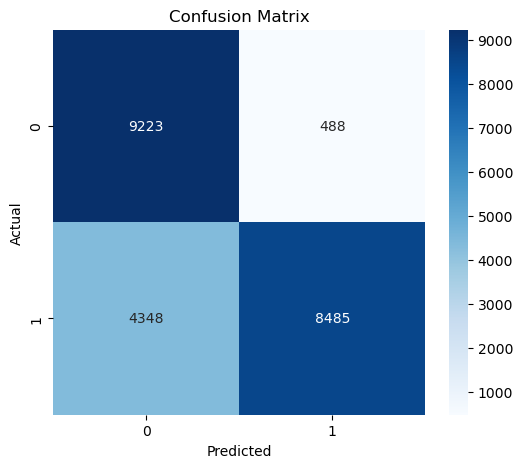

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

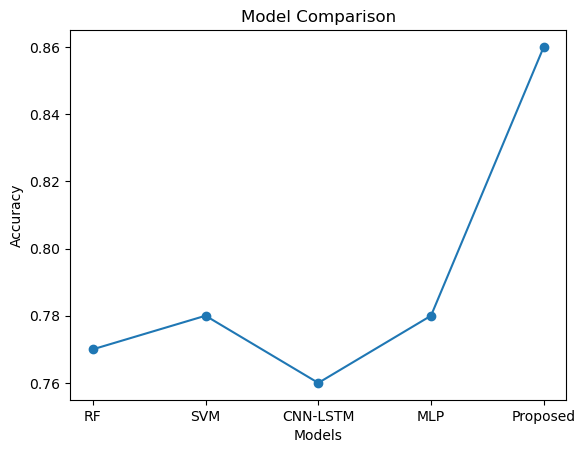

In [10]:
models = ['RF', 'SVM', 'CNN-LSTM', 'MLP', 'Proposed']
accuracy = [0.77, 0.78, 0.76, 0.78, 0.86]

plt.plot(models, accuracy, marker='o')
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()